In [89]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [90]:
df = pd.read_csv('transactions_raw.csv', encoding='utf-8', encoding_errors='ignore')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [91]:
df.shape

(541909, 8)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## Cleaning

### Handle missing values

In [93]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [94]:
# drop rows with missing CustomerID
before_missing = len(df)
df = df.dropna(subset=['CustomerID'])
after_missing = len(df)

print(f"Rows before:{before_missing}")
print(f"Rows after: {after_missing}")

Rows before:541909
Rows after: 406829


### Handle duplicates

In [95]:
df.duplicated().sum()

5225

In [96]:
df[df.duplicated(keep=False)].sort_values(by=['InvoiceNo', 'StockCode'])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,11/4/2011 13:25,2.95,15110.0,United Kingdom
461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom
461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom
529980,C580764,22667,RECIPE BOX RETROSPOT,-12,12/6/2011 10:38,2.95,14562.0,United Kingdom


In [97]:
before_duplicate = len(df)
df = df.drop_duplicates()
after_duplicate = len(df)

print(f"Rows before:{before_duplicate}")
print(f"Rows after: {after_duplicate}")

Rows before:406829
Rows after: 401604


### Handle entry errors: quantity and unit price

In [98]:
invalid_rows = ((df['Quantity'] <= 0) | (df['UnitPrice'] <= 0)).sum()

print(f"Number of rows where Quantity <= 0 or UnitPrice <= 0: {invalid_rows}")

Number of rows where Quantity <= 0 or UnitPrice <= 0: 8912


In [99]:
before = len(df)

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

after = len(df)

print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Rows removed: {before - after}")

Rows before: 401604
Rows after: 392692
Rows removed: 8912


### Converting Data Types

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


In [101]:
df['CustomerID'] = df['CustomerID'].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int32         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(4)
memory usage: 25.5+ MB


In [102]:
df['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)

In [103]:
# Convert to categorical dtype to reduce memory usage
df["Country"] = df["Country"].astype("category")

## Summary statistics and Outliers

In [104]:
df[['Quantity','UnitPrice']].describe([0.01, 0.05, 0.10, 0.20, 0.90, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,10%,20%,50%,90%,95%,99%,max
Quantity,392692.0,13.119702,180.492832,1.000,1.00,1.00,1.00,2.00,6.00,24.00,36.0,120.00,80995.00
UnitPrice,392692.0,3.125914,22.241836,0.001,0.21,0.42,0.55,0.85,1.95,6.35,8.5,14.95,8142.75


In [105]:
df[df['Quantity'] > 120].sort_values('Quantity', ascending=False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087,United Kingdom
...,...,...,...,...,...,...,...,...
384249,570113,22959,WRAP CHRISTMAS VILLAGE,125,2011-10-07 12:31:00,0.42,15874,United Kingdom
348314,567423,22666,RECIPE BOX PANTRY YELLOW DESIGN,124,2011-09-20 11:05:00,3.20,17450,United Kingdom
304642,563590,22666,RECIPE BOX PANTRY YELLOW DESIGN,124,2011-08-17 20:02:00,3.20,17450,United Kingdom
424324,573263,21163,DO NOT TOUCH MY STUFF DOOR HANGER,121,2011-10-28 12:34:00,0.39,13694,United Kingdom


In [106]:
df.nsmallest(1,'UnitPrice')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
157195,550193,PADS,PADS TO MATCH ALL CUSHIONS,1,2011-04-15 09:27:00,0.001,13952,United Kingdom


In [107]:
df.nlargest(20, 'UnitPrice')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029,United Kingdom
422351,573077,M,Manual,1,2011-10-27 14:13:00,4161.06,12536,France
422376,573080,M,Manual,1,2011-10-27 14:20:00,4161.06,12536,France
406406,571751,M,Manual,1,2011-10-19 11:18:00,3949.32,12744,Singapore
374542,569382,M,Manual,1,2011-10-03 16:44:00,3155.95,15502,United Kingdom
297438,562946,M,Manual,1,2011-08-11 09:38:00,2500.00,15581,United Kingdom
144826,548813,M,Manual,1,2011-04-04 13:03:00,2382.92,12744,Singapore
406407,571751,M,Manual,1,2011-10-19 11:18:00,2118.74,12744,Singapore
144829,548820,M,Manual,1,2011-04-04 13:04:00,2053.07,12744,Singapore
343000,566927,M,Manual,1,2011-09-15 15:20:00,2033.10,17846,United Kingdom


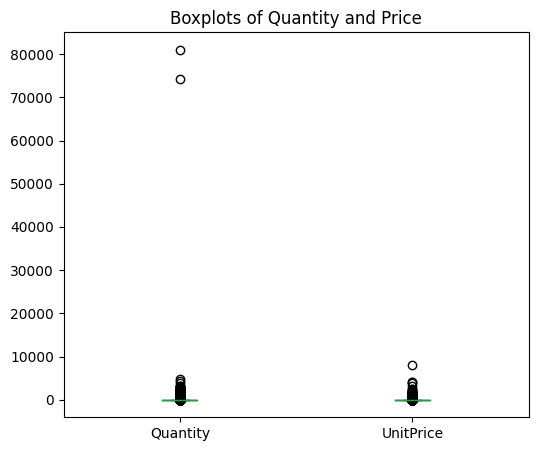

In [108]:
df[["Quantity", "UnitPrice"]].plot(kind="box", figsize=(6, 5))
plt.title("Boxplots of Quantity and Price")
plt.show()

### Create TotalPrice column

In [109]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int32         
 7   Country      392692 non-null  category      
 8   TotalPrice   392692 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(2), int32(1), int64(1), object(3)
memory usage: 25.8+ MB


In [111]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Export

In [112]:
df.to_csv('transactions_clean.csv', index=False)